This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

## Local Setup for p12 Server

This notebook is configured to run on the **p12 server** (8x RTX 2080 Ti, NVIDIA driver 520.56.06).

### Quick Start

```bash
# SSH to p12
ssh p12
cd ~/projects/deep-learning-with-python-notebooks

# Start Jupyter (use the existing kernel "DLWP TF2.12 GPU")
source .venv-tf215/bin/activate
jupyter lab --no-browser
```

From your local machine, create an SSH tunnel:
```bash
ssh -L 8888:localhost:8888 p12
```
Then open http://127.0.0.1:8888/lab?token=<token>

**Important:** Select the kernel **"DLWP TF2.12 GPU"** in Jupyter. This kernel has the GPU environment variables pre-configured.

### First-Time Setup (if .venv-tf215 doesn't exist)

The p12 server has NVIDIA driver 520, which only supports CUDA 11.x. We use TensorFlow 2.12 (built with CUDA 11.8) with Keras 3.12 and bundled CUDA libraries.

```bash
# 1. Create venv with Python 3.11 (required for TensorFlow 2.12)
python3.11 -m venv .venv-tf215
source .venv-tf215/bin/activate

# 2. Install TensorFlow 2.12 and CUDA 11 libraries
pip install tensorflow==2.12.1
pip install nvidia-cudnn-cu11==8.6.0.163 nvidia-cublas-cu11 nvidia-cuda-runtime-cu11 \
    nvidia-cuda-nvrtc-cu11 nvidia-cufft-cu11 nvidia-curand-cu11 \
    nvidia-cusolver-cu11 nvidia-cusparse-cu11 nvidia-cuda-nvcc-cu11

# 3. Install Keras 3 and other dependencies (numpy<2 for TF 2.12 compat)
pip install keras==3.12.0 'numpy==1.24.3' matplotlib regex ipykernel

# 4. Register the kernel with GPU environment variables
# (The kernel.json includes LD_LIBRARY_PATH and XLA_FLAGS)
python -m ipykernel install --user --name=dlwp-tf212 --display-name="DLWP TF2.12 GPU"
# Then manually edit ~/.local/share/jupyter/kernels/dlwp-tf212/kernel.json 
# to add the "env" section with LD_LIBRARY_PATH, XLA_FLAGS, CUDA_VISIBLE_DEVICES
```

**Note:** On shared GPU servers, we restrict to GPUs 0-3 via CUDA_VISIBLE_DEVICES.

In [1]:
# Verify we're using the correct virtual environment
import sys
print(sys.executable)

/Users/dmeyer/.claude-worktrees/deep-learning-with-python-notebooks/agitated-raman/.venv/bin/python3


In [ ]:
# Install/upgrade Keras and keras-hub
# IMPORTANT: numpy<2 is required for TensorFlow 2.12 compatibility
!pip install keras keras-hub 'numpy<2' --upgrade -q

In [ ]:
# Set the backend BEFORE importing keras
# 
# IMPORTANT: For GPU support, your backend choice depends on your NVIDIA driver version:
#   - Driver 525+: Use "tensorflow" (with tensorflow[and-cuda] installed)
#   - Driver <525: Use "torch" (with PyTorch CUDA 11.8 installed)
#
# To force a specific backend, uncomment one of these lines:
# os.environ["KERAS_BACKEND"] = "tensorflow"
# os.environ["KERAS_BACKEND"] = "torch"
# os.environ["KERAS_BACKEND"] = "jax"

import os
import importlib.util

def get_available_backend():
    """Select the best available Keras backend.
    
    Order of preference: TensorFlow, PyTorch, JAX
    Note: Even if TensorFlow is installed, it may not work with GPU on older drivers.
    In that case, manually set KERAS_BACKEND="torch" above.
    """
    backends = [
        ("tensorflow", "tensorflow"),
        ("torch", "torch"),
        ("jax", "jax"),
    ]
    
    for backend_name, module_name in backends:
        if importlib.util.find_spec(module_name) is not None:
            try:
                __import__(module_name)
                print(f"Using backend: {backend_name}")
                return backend_name
            except ImportError as e:
                print(f"Backend {backend_name} found but failed to import: {e}")
                continue
    
    raise RuntimeError("No Keras backend available. Install tensorflow, torch, or jax.")

# Only auto-detect if not already set
if "KERAS_BACKEND" not in os.environ:
    os.environ["KERAS_BACKEND"] = get_available_backend()
else:
    print(f"Using backend: {os.environ['KERAS_BACKEND']} (manually set)")

In [ ]:
# GPU Detection - verify the kernel has GPU support configured
# 
# If using the "DLWP TF2.12 GPU" kernel, LD_LIBRARY_PATH and XLA_FLAGS
# are already set in the kernel.json, so GPUs should be detected.

import os

backend = os.environ.get("KERAS_BACKEND", "tensorflow")

if backend == "tensorflow":
    import tensorflow as tf
    
    gpus = tf.config.list_physical_devices('GPU')
    if gpus:
        print(f"TensorFlow {tf.__version__} detected {len(gpus)} GPU(s):")
        for i, gpu in enumerate(gpus):
            print(f"  GPU {i}: {gpu.name}")
        
        # Enable memory growth to avoid allocating all GPU memory at once
        for gpu in gpus:
            try:
                tf.config.experimental.set_memory_growth(gpu, True)
            except RuntimeError as e:
                print(f"  Warning: Could not set memory growth: {e}")
    else:
        print("No GPU detected!")
        print("Make sure you're using the 'DLWP TF2.12 GPU' kernel.")
        print("Check: Kernel > Change Kernel > DLWP TF2.12 GPU")

elif backend == "jax":
    import jax
    devices = jax.devices()
    print(f"JAX detected {len(devices)} device(s):")
    for d in devices:
        print(f"  {d}")

elif backend == "torch":
    import torch
    if torch.cuda.is_available():
        print(f"PyTorch detected {torch.cuda.device_count()} GPU(s):")
        for i in range(torch.cuda.device_count()):
            print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
    else:
        print("No GPU detected. Running on CPU.")

print(f"\nUsing backend: {backend}")

In [4]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Text classification

### A brief history of natural language processing

### Preparing text data

In [5]:
import regex as re

def split_chars(text):
    return re.findall(r".", text)

In [6]:
chars = split_chars("The quick brown fox jumped over the lazy dog.")
chars[:12]

['T', 'h', 'e', ' ', 'q', 'u', 'i', 'c', 'k', ' ', 'b', 'r']

In [7]:
def split_words(text):
    return re.findall(r"[\w]+|[.,!?;]", text)

In [8]:
split_words("The quick brown fox jumped over the dog.")

['The', 'quick', 'brown', 'fox', 'jumped', 'over', 'the', 'dog', '.']

In [9]:
vocabulary = {
    "[UNK]": 0,
    "the": 1,
    "quick": 2,
    "brown": 3,
    "fox": 4,
    "jumped": 5,
    "over": 6,
    "dog": 7,
    ".": 8,
}
words = split_words("The quick brown fox jumped over the lazy dog.")
indices = [vocabulary.get(word, 0) for word in words]

#### Character and word tokenization

In [10]:
class CharTokenizer:
    def __init__(self, vocabulary):
        self.vocabulary = vocabulary
        self.unk_id = vocabulary["[UNK]"]

    def standardize(self, inputs):
        return inputs.lower()

    def split(self, inputs):
        return re.findall(r".", inputs)

    def index(self, tokens):
        return [self.vocabulary.get(t, self.unk_id) for t in tokens]

    def __call__(self, inputs):
        inputs = self.standardize(inputs)
        tokens = self.split(inputs)
        indices = self.index(tokens)
        return indices

In [11]:
import collections

def compute_char_vocabulary(inputs, max_size):
    char_counts = collections.Counter()
    for x in inputs:
        x = x.lower()
        tokens = re.findall(r".", x)
        char_counts.update(tokens)
    vocabulary = ["[UNK]"]
    most_common = char_counts.most_common(max_size - len(vocabulary))
    for token, count in most_common:
        vocabulary.append(token)
    return dict((token, i) for i, token in enumerate(vocabulary))

In [12]:
class WordTokenizer:
    def __init__(self, vocabulary):
        self.vocabulary = vocabulary
        self.unk_id = vocabulary["[UNK]"]

    def standardize(self, inputs):
        return inputs.lower()

    def split(self, inputs):
        return re.findall(r"[\w]+|[.,!?;]", inputs)

    def index(self, tokens):
        return [self.vocabulary.get(t, self.unk_id) for t in tokens]

    def __call__(self, inputs):
        inputs = self.standardize(inputs)
        tokens = self.split(inputs)
        indices = self.index(tokens)
        return indices

In [13]:
def compute_word_vocabulary(inputs, max_size):
    word_counts = collections.Counter()
    for x in inputs:
        x = x.lower()
        tokens = re.findall(r"[\w]+|[.,!?;]", x)
        word_counts.update(tokens)
    vocabulary = ["[UNK]"]
    most_common = word_counts.most_common(max_size - len(vocabulary))
    for token, count in most_common:
        vocabulary.append(token)
    return dict((token, i) for i, token in enumerate(vocabulary))

In [14]:
import keras

filename = keras.utils.get_file(
    origin="https://www.gutenberg.org/files/2701/old/moby10b.txt",
)
moby_dick = list(open(filename, "r"))

vocabulary = compute_char_vocabulary(moby_dick, max_size=100)
char_tokenizer = CharTokenizer(vocabulary)

In [15]:
print("Vocabulary length:", len(vocabulary))

Vocabulary length: 64


In [16]:
print("Vocabulary start:", list(vocabulary.keys())[:10])

Vocabulary start: ['[UNK]', ' ', 'e', 't', 'a', 'o', 'n', 'i', 's', 'h']


In [17]:
print("Vocabulary end:", list(vocabulary.keys())[-10:])

Vocabulary end: ['@', '$', '%', '#', '=', '~', '&', '+', '<', '>']


In [18]:
print("Line length:", len(char_tokenizer(
   "Call me Ishmael. Some years ago--never mind how long precisely."
)))

Line length: 63


In [19]:
vocabulary = compute_word_vocabulary(moby_dick, max_size=2_000)
word_tokenizer = WordTokenizer(vocabulary)

In [20]:
print("Vocabulary length:", len(vocabulary))

Vocabulary length: 2000


In [21]:
print("Vocabulary start:", list(vocabulary.keys())[:5])

Vocabulary start: ['[UNK]', ',', 'the', '.', 'of']


In [22]:
print("Vocabulary end:", list(vocabulary.keys())[-5:])

Vocabulary end: ['tambourine', 'subtle', 'perseus', 'elevated', 'repose']


In [23]:
print("Line length:", len(word_tokenizer(
   "Call me Ishmael. Some years ago--never mind how long precisely."
)))

Line length: 13


#### Subword tokenization

In [24]:
data = [
    "the quick brown fox",
    "the slow brown fox",
    "the quick brown foxhound",
]

In [25]:
def count_and_split_words(data):
    counts = collections.Counter()
    for line in data:
        line = line.lower()
        for word in re.findall(r"[\w]+|[.,!?;]", line):
            chars = re.findall(r".", word)
            split_word = " ".join(chars)
            counts[split_word] += 1
    return dict(counts)

counts = count_and_split_words(data)

In [26]:
counts

{'t h e': 3,
 'q u i c k': 2,
 'b r o w n': 3,
 'f o x': 2,
 's l o w': 1,
 'f o x h o u n d': 1}

In [27]:
def count_pairs(counts):
    """Count total occurrences of each adjacent symbol pair across all words.
    
    For each word, finds all adjacent pairs and adds the word's frequency
    to each pair's count. If a pair appears multiple times in the same word
    (e.g., 'abab' has 'ab' twice), it's counted multiple times.
    
    Example:
        counts = {'t h e': 3, 'f o x': 2}
        -> {('t','h'): 3, ('h','e'): 3, ('f','o'): 2, ('o','x'): 2}
    """
    pairs = collections.Counter()
    for word, freq in counts.items():
        symbols = word.split()
        for pair in zip(symbols[:-1], symbols[1:]):
            pairs[pair] += freq
    return pairs

def merge_pair(counts, first, second):
    """Merge a pair of symbols into a single token everywhere it appears.
    
    This is one step of BPE: the most frequent adjacent pair gets combined.
    The merged token becomes a new symbol that can participate in future merges.
    
    Example:
        counts = {'t h e': 3, 'f o x': 2}
        merge_pair(counts, 't', 'h')
        -> {'th e': 3, 'f o x': 2}
        
        # Now 'th' is a single symbol. Next iteration might merge 'th'+'e':
        merge_pair(counts, 'th', 'e')
        -> {'the': 3, 'f o x': 2}
    """
    split = re.compile(f"(?<!\S){first} {second}(?!\S)")
    merged = f"{first}{second}"
    return {split.sub(merged, word): count for word, count in counts.items()}

for i in range(10):
    pairs = count_pairs(counts)
    first, second = max(pairs, key=pairs.get)
    counts = merge_pair(counts, first, second)
    print(list(counts.keys()))

['t h e', 'q u i c k', 'b r ow n', 'f o x', 's l ow', 'f o x h o u n d']
['th e', 'q u i c k', 'b r ow n', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'b r ow n', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'br ow n', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'brow n', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'brown', 'f o x', 's l ow', 'f o x h o u n d']
['the', 'q u i c k', 'brown', 'fo x', 's l ow', 'fo x h o u n d']
['the', 'q u i c k', 'brown', 'fox', 's l ow', 'fox h o u n d']
['the', 'qu i c k', 'brown', 'fox', 's l ow', 'fox h o u n d']
['the', 'qui c k', 'brown', 'fox', 's l ow', 'fox h o u n d']


In [28]:
def compute_sub_word_vocabulary(dataset, vocab_size):
    """Build a BPE (Byte Pair Encoding) vocabulary from a dataset.
    
    BPE finds a middle ground between character and word tokenization by
    iteratively merging the most frequent adjacent pairs of symbols.
    
    Process:
        1. Start with all individual characters as the base vocabulary
        2. Count adjacent pairs across all words
        3. Merge the most frequent pair into a new token
        4. Repeat until vocab reaches target size
    
    Args:
        dataset: List of text strings to build vocabulary from
        vocab_size: Target vocabulary size (e.g., 2000)
    
    Returns:
        vocab: dict mapping token -> index
               e.g., {'[UNK]': 0, 'e': 1, 't': 2, ..., 'th': 50, 'the': 51, ...}
        merges: dict mapping merge rule -> rank (priority)
                e.g., {'t h': 0, 'th e': 1, ...}
                Lower rank = higher priority when tokenizing new text
    """
    # Split all words into space-separated characters and count them
    counts = count_and_split_words(dataset)
    # e.g., {'t h e': 3, 'f o x': 2, ...}

    # Build initial vocab from all characters, sorted by frequency
    char_counts = collections.Counter()
    for word in counts:
        for char in word.split():
            char_counts[char] += counts[word]
    most_common = char_counts.most_common()
    vocab = ["[UNK]"] + [char for char, freq in most_common]
    merges = []

    # BPE merge loop: keep merging until we reach vocab_size
    while len(vocab) < vocab_size:
        pairs = count_pairs(counts)
        if not pairs:
            break
        first, second = max(pairs, key=pairs.get)
        counts = merge_pair(counts, first, second)
        vocab.append(f"{first}{second}")   # Add merged token to vocab
        merges.append(f"{first} {second}") # Record merge rule

    # Convert to dicts for fast lookup
    vocab = dict((token, index) for index, token in enumerate(vocab))
    merges = dict((token, rank) for rank, token in enumerate(merges))
    return vocab, merges

In [29]:
class SubWordTokenizer:
    """Tokenizer that applies BPE (Byte Pair Encoding) to convert text to token indices.
    
    Uses a pre-built vocabulary and merge rules to tokenize new text.
    
    Pipeline:
        "Hello" → "hello" → "h e l l o" → "hel lo" → [42, 87]
                  standardize   split     bpe_merge   index
    
    Example:
        vocab, merges = compute_sub_word_vocabulary(data, 2000)
        tokenizer = SubWordTokenizer(vocab, merges)
        tokenizer("Hello world!")  # → [42, 87, 103, 8]
    """
    
    def __init__(self, vocabulary, merges):
        """Initialize with pre-built vocabulary and merge rules.
        
        Args:
            vocabulary: dict mapping token -> index (from compute_sub_word_vocabulary)
            merges: dict mapping merge rule -> rank (from compute_sub_word_vocabulary)
        """
        self.vocabulary = vocabulary
        self.merges = merges
        self.unk_id = vocabulary["[UNK]"]

    def standardize(self, inputs):
        """Normalize text by lowercasing."""
        return inputs.lower()

    def bpe_merge(self, word):
        """Apply BPE merges to a space-separated word.
        
        Repeatedly finds the highest-priority merge (lowest rank) and applies it
        until no more merges are possible.
        
        Args:
            word: Space-separated characters, e.g., "h e l l o"
        
        Returns:
            Partially merged word, e.g., "hel lo"
        
        Example:
            "h e l l o"
            → find pairs: ['h e', 'e l', 'l l', 'l o']
            → best merge (lowest rank): 'l o' (rank 5)
            → "h e l lo"
            → find pairs: ['h e', 'e l', 'l lo']
            → best merge: 'e l' (rank 12)
            → "h el lo"
            → ... continues until no pairs in merges dict
        """
        while True:
            # Find all adjacent pairs in the word
            pairs = re.findall(r"(?<!\S)\S+ \S+(?!\S)", word, overlapped=True)
            if not pairs:
                break
            # Find pair with lowest merge rank (1e9 = not in merges, never merge)
            best = min(pairs, key=lambda pair: self.merges.get(pair, 1e9))
            if best not in self.merges:
                break
            # Apply the merge
            first, second = best.split()
            split = re.compile(f"(?<!\S){first} {second}(?!\S)")
            merged = f"{first}{second}"
            word = split.sub(merged, word)
        return word

    def split(self, inputs):
        """Split text into subword tokens using BPE.
        
        Args:
            inputs: Text string, e.g., "Hello world"
        
        Returns:
            List of subword tokens, e.g., ['hel', 'lo', 'wor', 'ld']
        
        Process:
            1. Split into words: ["Hello", "world"]
            2. Each word → space-separated chars: ["h e l l o", "w o r l d"]
            3. Apply bpe_merge to each: ["hel lo", "wor ld"]
            4. Split on spaces → final tokens: ['hel', 'lo', 'wor', 'ld']
        """
        tokens = []
        for word in re.findall(r"[\w]+|[.,!?;]", inputs):
            word = " ".join(re.findall(r".", word))  # "hello" → "h e l l o"
            word = self.bpe_merge(word)               # "h e l l o" → "hel lo"
            tokens.extend(word.split())               # ['hel', 'lo']
        return tokens

    def index(self, tokens):
        """Convert tokens to vocabulary indices.
        
        Unknown tokens (not in vocabulary) get mapped to [UNK] index.
        """
        return [self.vocabulary.get(t, self.unk_id) for t in tokens]

    def __call__(self, inputs):
        """Tokenize text: string → list of token indices.
        
        Args:
            inputs: Text string, e.g., "Hello world!"
        
        Returns:
            List of token indices, e.g., [42, 87, 103, 8]
        """
        inputs = self.standardize(inputs)
        tokens = self.split(inputs)
        indices = self.index(tokens)
        return indices

In [30]:
vocabulary, merges = compute_sub_word_vocabulary(moby_dick, 2_000)
sub_word_tokenizer = SubWordTokenizer(vocabulary, merges)

In [31]:
print("Vocabulary length:", len(vocabulary))

Vocabulary length: 2000


In [32]:
print("Vocabulary start:", list(vocabulary.keys())[:10])

Vocabulary start: ['[UNK]', 'e', 't', 'a', 'o', 'n', 'i', 's', 'h', 'r']


In [33]:
print("Vocabulary end:", list(vocabulary.keys())[-7:])

Vocabulary end: ['bright', 'pilot', 'sco', 'ben', 'dem', 'gale', 'ilo']


In [34]:
print("Line length:", len(sub_word_tokenizer(
   "Call me Ishmael. Some years ago--never mind how long precisely."
)))

Line length: 16


### Sets vs. sequences

#### Loading the IMDb classification dataset

In [35]:
import os, pathlib, shutil, random

zip_path = keras.utils.get_file(
    origin="https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz",
    fname="imdb",
    extract=True,
)

imdb_extract_dir = pathlib.Path(zip_path) / "aclImdb"

In [36]:
for path in imdb_extract_dir.glob("*/*"):
    if path.is_dir():
        print(path)

/Users/dmeyer/.keras/datasets/imdb/aclImdb/test/neg
/Users/dmeyer/.keras/datasets/imdb/aclImdb/test/pos
/Users/dmeyer/.keras/datasets/imdb/aclImdb/train/neg
/Users/dmeyer/.keras/datasets/imdb/aclImdb/train/unsup
/Users/dmeyer/.keras/datasets/imdb/aclImdb/train/pos


In [37]:
print(open(imdb_extract_dir / "train" / "pos" / "4077_10.txt", "r").read())

I first saw this back in the early 90s on UK TV, i did like it then but i missed the chance to tape it, many years passed but the film always stuck with me and i lost hope of seeing it TV again, the main thing that stuck with me was the end, the hole castle part really touched me, its easy to watch, has a great story, great music, the list goes on and on, its OK me saying how good it is but everyone will take there own best bits away with them once they have seen it, yes the animation is top notch and beautiful to watch, it does show its age in a very few parts but that has now become part of it beauty, i am so glad it has came out on DVD as it is one of my top 10 films of all time. Buy it or rent it just see it, best viewing is at night alone with drink and food in reach so you don't have to stop the film.<br /><br />Enjoy


In [38]:
# Create train/val/test split from the original dataset
# Original dataset only has train/ and test/, but we need a validation set
# to tune hyperparameters and detect overfitting without touching the test set.

train_dir = pathlib.Path("imdb_train")
test_dir = pathlib.Path("imdb_test")
val_dir = pathlib.Path("imdb_val")

# Copy test set as-is (25,000 reviews)
shutil.copytree(imdb_extract_dir / "test", test_dir)

# Split original training set into 80% train, 20% validation
val_percentage = 0.2
for category in ("neg", "pos"):
    src_dir = imdb_extract_dir / "train" / category
    src_files = os.listdir(src_dir)
    random.Random(1337).shuffle(src_files)  # Seeded shuffle for reproducibility
    num_val_samples = int(len(src_files) * val_percentage)

    # First 20% → validation set (2,500 per category = 5,000 total)
    os.makedirs(val_dir / category)
    for file in src_files[:num_val_samples]:
        shutil.copy(src_dir / file, val_dir / category / file)
    
    # Remaining 80% → training set (10,000 per category = 20,000 total)
    os.makedirs(train_dir / category)
    for file in src_files[num_val_samples:]:
        shutil.copy(src_dir / file, train_dir / category / file)

FileExistsError: [Errno 17] File exists: 'imdb_test'

In [39]:
from keras.utils import text_dataset_from_directory

batch_size = 32
train_ds = text_dataset_from_directory(train_dir, batch_size=batch_size)
val_ds = text_dataset_from_directory(val_dir, batch_size=batch_size)
test_ds = text_dataset_from_directory(test_dir, batch_size=batch_size)

Found 20000 files belonging to 2 classes.
Found 5000 files belonging to 2 classes.
Found 25000 files belonging to 2 classes.


### Set models

#### Training a bag-of-words model

In [40]:
from keras import layers

# Bag-of-Words: represent text as a binary vector of word presence
# "The movie was great" → [1, 1, 1, 1, 0, 0, ...] (20,000 dims)
# Note: word ORDER is lost, and word COUNT is lost (multi_hot = binary)

max_tokens = 20_000  # Keep only the 20,000 most frequent words
text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    split="whitespace",      # Simple split on spaces (no BPE)
    output_mode="multi_hot", # Binary: 1 if word present, 0 if absent
)

# Learn vocabulary from training data only (not val/test to avoid data leakage)
train_ds_no_labels = train_ds.map(lambda x, y: x)  # Strip labels, keep text
text_vectorization.adapt(train_ds_no_labels)        # Build vocabulary

# Apply vectorization to all datasets
# Each text becomes a 20,000-dim binary vector
bag_of_words_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
bag_of_words_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
bag_of_words_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

In [41]:
x, y = next(bag_of_words_train_ds.as_numpy_iterator())
x.shape

(32, 20000)

In [42]:
y.shape

(32,)

In [43]:
def build_linear_classifier(max_tokens, name):
    """Build a single-layer linear classifier for binary sentiment analysis.
    
    Architecture: Input (20,000) → Dense(1, sigmoid) → Output (1)
    
    The model learns one weight per word:
        output = sigmoid(w₀·word₀ + w₁·word₁ + ... + w₁₉₉₉₉·word₁₉₉₉₉ + bias)
    
    Positive weights → word indicates positive review (e.g., "great")
    Negative weights → word indicates negative review (e.g., "terrible")
    
    Total parameters: 20,001 (20,000 weights + 1 bias)
    """
    inputs = keras.Input(shape=(max_tokens,))  # 20,000-dim bag-of-words vector
    outputs = layers.Dense(1, activation="sigmoid")(inputs)  # Single neuron, outputs 0-1 probability
    model = keras.Model(inputs, outputs, name=name)
    model.compile(
        optimizer="adam",              # Adaptive learning rate optimizer
        loss="binary_crossentropy",    # Standard loss for binary classification
        metrics=["accuracy"],
    )
    return model

model = build_linear_classifier(max_tokens, "bag_of_words_classifier")

In [44]:
model.summary(line_length=80)

Model: "bag_of_words_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)          │ (None, 20000)            │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense (Dense)                     │ (None, 1)                │        20,001 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 20,001 (78.13 KB)

 Trainable params: 20,001 (78.13 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# Early stopping: stop training when validation loss stops improving
# This prevents overfitting - when the model memorizes training data
# but gets worse at generalizing to new data.
#
# Example:
#   Epoch 3: val_loss=0.33 ← best
#   Epoch 4: val_loss=0.35 ← worse (patience count: 1)
#   Epoch 5: val_loss=0.38 ← worse (patience count: 2) → STOP
#   → restore_best_weights rolls back to epoch 3's model

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",        # Watch validation loss, not training loss
    restore_best_weights=True, # Keep the best model, not the last one
    patience=2,                # Stop if no improvement for 2 consecutive epochs
)

history = model.fit(
    bag_of_words_train_ds,              # Training data (20,000 reviews)
    validation_data=bag_of_words_val_ds, # Validation data (5,000 reviews)
    epochs=10,                           # Train for at most 10 epochs
    callbacks=[early_stopping],          # May stop earlier if overfitting
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7829 - loss: 0.5416 - val_accuracy: 0.8750 - val_loss: 0.3611
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9047 - loss: 0.3061 - val_accuracy: 0.8838 - val_loss: 0.3081
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9258 - loss: 0.2420 - val_accuracy: 0.8898 - val_loss: 0.2872
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9381 - loss: 0.2062 - val_accuracy: 0.8888 - val_loss: 0.2767
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9489 - loss: 0.1789 - val_accuracy: 0.8898 - val_loss: 0.2713
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9576 - loss: 0.1592 - val_accuracy: 0.8906 - val_loss: 0.2693
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9626 - loss: 0.1427 - val_accuracy: 0.8894 - val_loss: 0.2686
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9674 - loss: 0.1288 - val_accuracy: 0.

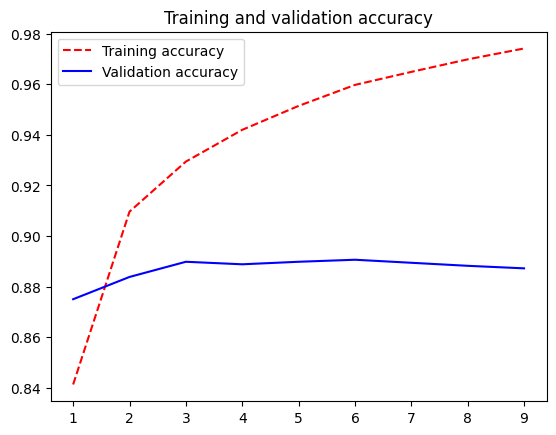

In [46]:
import matplotlib.pyplot as plt

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
epochs = range(1, len(accuracy) + 1)

plt.plot(epochs, accuracy, "r--", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.show()

In [47]:
test_loss, test_acc = model.evaluate(bag_of_words_test_ds)
test_acc

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8862 - loss: 0.2861


0.8869199752807617

#### Training a bigram model

In [48]:
max_tokens = 30_000
text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    split="whitespace",
    output_mode="multi_hot",
    ngrams=2,
)
text_vectorization.adapt(train_ds_no_labels)

bigram_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
bigram_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
bigram_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

In [49]:
x, y = next(bigram_train_ds.as_numpy_iterator())
x.shape

(32, 30000)

In [50]:
text_vectorization.get_vocabulary()[100:108]

[np.str_('in a'),
 np.str_('most'),
 np.str_('him'),
 np.str_('dont'),
 np.str_('it was'),
 np.str_('one of'),
 np.str_('then'),
 np.str_('made')]

In [51]:
model = build_linear_classifier(max_tokens, "bigram_classifier")
model.fit(
    bigram_train_ds,
    validation_data=bigram_val_ds,
    epochs=10,
    callbacks=[early_stopping],
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8153 - loss: 0.4907 - val_accuracy: 0.8910 - val_loss: 0.3049
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9307 - loss: 0.2356 - val_accuracy: 0.8982 - val_loss: 0.2672
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9564 - loss: 0.1719 - val_accuracy: 0.8972 - val_loss: 0.2542
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9723 - loss: 0.1335 - val_accuracy: 0.8980 - val_loss: 0.2495
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9801 - loss: 0.1064 - val_accuracy: 0.8954 - val_loss: 0.2491
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9865 - loss: 0.0865 - val_accuracy: 0.8942 - val_loss: 0.2512
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9927 - loss: 0.0708 - val_accuracy: 0.8928 - val_loss: 0.2548


In [52]:
test_loss, test_acc = model.evaluate(bigram_test_ds)
test_acc

782/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8994 - loss: 0.2556


0.901639997959137

### Sequence models

In [53]:
# Sequence representation: preserve word ORDER (unlike bag-of-words)
# Output is a sequence of token IDs, not a binary vector.
#
# Example: "The movie was great"
#   bag-of-words: [1, 1, 1, 1, 0, 0, ...]  # 30,000-dim, order lost
#   sequence:     [2, 45, 12, 89, 0, 0, ...]  # 600 token IDs, order preserved
#
# This enables models (LSTM, Transformer) that read text left-to-right.

max_length = 600    # Pad/truncate all reviews to 600 tokens
max_tokens = 30_000 # Vocabulary size

text_vectorization = layers.TextVectorization(
    max_tokens=max_tokens,
    split="whitespace",           # Still simple whitespace tokenization (no BPE)
    output_mode="int",            # Return token IDs, not binary vector
    output_sequence_length=max_length,  # Fixed length: pad short, truncate long
)
text_vectorization.adapt(train_ds_no_labels)

# Output shape: (batch_size, 600) - each review is 600 token IDs
sequence_train_ds = train_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
sequence_val_ds = val_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)
sequence_test_ds = test_ds.map(
    lambda x, y: (text_vectorization(x), y), num_parallel_calls=8
)

In [54]:
x, y = next(sequence_test_ds.as_numpy_iterator())
x.shape

(32, 600)

In [55]:
x

array([[   85,  3049,    44, ...,     0,     0,     0],
       [ 1781,    36,  1260, ...,     0,     0,     0],
       [28351,     1,   580, ...,     0,     0,     0],
       ...,
       [   55,    85,     1, ...,    14,    22,    12],
       [   15,     4,   334, ...,     0,     0,     0],
       [   11,    18,   183, ...,     0,     0,     0]])

In [56]:
y.shape

(32,)

#### Training a recurrent model

In [59]:
from keras import ops

class OneHotEncoding(keras.Layer):
    """Convert token IDs to one-hot vectors.
    
    One-hot encoding represents each token as a sparse vector with a single 1:
        token_id=2, depth=5  →  [0, 0, 1, 0, 0]
    
    Input shape:  (batch_size, sequence_length)         e.g., (32, 600)
    Output shape: (batch_size, sequence_length, depth)  e.g., (32, 600, 30000)
    
    Note: Very memory-intensive! Each token becomes a 30,000-dim vector.
    Embeddings (next section) are much more efficient.
    """
    
    def __init__(self, depth, **kwargs):
        super().__init__(**kwargs)
        self.depth = depth  # Vocabulary size (30,000)

    def call(self, inputs):
        # Flatten: (32, 600) → (19200,) - one long list of token IDs
        flat_inputs = ops.reshape(ops.cast(inputs, "int"), [-1])
        
        # Identity matrix: row i = one-hot vector for token i
        # Shape: (30000, 30000)
        one_hot_vectors = ops.eye(self.depth)
        
        # Look up each token ID → get its one-hot vector
        # Shape: (19200, 30000)
        outputs = ops.take(one_hot_vectors, flat_inputs, axis=0)
        
        # Reshape back to batch structure: (19200, 30000) → (32, 600, 30000)
        return ops.reshape(outputs, ops.shape(inputs) + (self.depth,))

one_hot_encoding = OneHotEncoding(max_tokens)

In [60]:
x, y = next(sequence_train_ds.as_numpy_iterator())
one_hot_encoding(x).shape

TensorShape([32, 600, 30000])

In [61]:
hidden_dim = 64
inputs = keras.Input(shape=(max_length,), dtype="int32")
x = one_hot_encoding(inputs)
x = layers.Bidirectional(layers.LSTM(hidden_dim))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs, name="lstm_with_one_hot")
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [62]:
model.summary(line_length=80)

Model: "lstm_with_one_hot"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)        │ (None, 600)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ one_hot_encoding_1                │ (None, 600, 30000)       │             0 │
│ (OneHotEncoding)                  │                          │               │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)     │ (None, 128)              │    15,393,280 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 128)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_2 (Dense)                   │ (None, 1)                │           129 │
└───────────────────────────────────┴──────────────────────────┴───────────────┘

 Total params: 15,393,409 (58.72 MB)

 Trainable params: 15,393,409 (58.72 MB)

 Non-trainable params: 0 (0.00 B)

In [63]:
# ⚠️NOTE⚠️: The following fit call will error on a T4 GPU on the TensorFlow
# backend due to a bug in TensorFlow. If you the follow cell errors out,
# do one of the following:
# - Skip the following two cells.
# - Switch to the Jax or Torch backend and re-run this notebook.
# - Change the GPU type in your runtime (requires Colab Pro as of this writing).

In [64]:
model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=10,
    callbacks=[early_stopping],
)

Epoch 1/10
 13/625 ━━━━━━━━━━━━━━━━━━━━ 53:14 5s/step - accuracy: 0.5642 - loss: 0.6923

KeyboardInterrupt: 

In [ ]:
test_loss, test_acc = model.evaluate(sequence_test_ds)
test_acc

#### Understanding word embeddings

#### Using a word embedding

In [ ]:
hidden_dim = 64
inputs = keras.Input(shape=(max_length,), dtype="int32")
x = keras.layers.Embedding(
    input_dim=max_tokens,
    output_dim=hidden_dim,
    mask_zero=True,
)(inputs)
x = keras.layers.Bidirectional(keras.layers.LSTM(hidden_dim))(x)
x = keras.layers.Dropout(0.5)(x)
outputs = keras.layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs, name="lstm_with_embedding")
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

In [ ]:
model.summary(line_length=80)

In [ ]:
model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=10,
    callbacks=[early_stopping],
)
test_loss, test_acc = model.evaluate(sequence_test_ds)
test_acc

#### Pretraining a word embedding

In [ ]:
imdb_vocabulary = text_vectorization.get_vocabulary()
tokenize_no_padding = keras.layers.TextVectorization(
    vocabulary=imdb_vocabulary,
    split="whitespace",
    output_mode="int",
)

In [ ]:
import tensorflow as tf

context_size = 4
window_size = 9

def window_data(token_ids):
    num_windows = tf.maximum(tf.size(token_ids) - context_size * 2, 0)
    windows = tf.range(window_size)[None, :]
    windows = windows + tf.range(num_windows)[:, None]
    windowed_tokens = tf.gather(token_ids, windows)
    return tf.data.Dataset.from_tensor_slices(windowed_tokens)

def split_label(window):
    left = window[:context_size]
    right = window[context_size + 1 :]
    bag = tf.concat((left, right), axis=0)
    label = window[4]
    return bag, label

dataset = keras.utils.text_dataset_from_directory(
    imdb_extract_dir / "train", batch_size=None
)
dataset = dataset.map(lambda x, y: x, num_parallel_calls=8)
dataset = dataset.map(tokenize_no_padding, num_parallel_calls=8)
dataset = dataset.interleave(window_data, cycle_length=8, num_parallel_calls=8)
dataset = dataset.map(split_label, num_parallel_calls=8)

In [ ]:
hidden_dim = 64
inputs = keras.Input(shape=(2 * context_size,))
cbow_embedding = layers.Embedding(
    max_tokens,
    hidden_dim,
)
x = cbow_embedding(inputs)
x = layers.GlobalAveragePooling1D()(x)
outputs = layers.Dense(max_tokens, activation="sigmoid")(x)
cbow_model = keras.Model(inputs, outputs)
cbow_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["sparse_categorical_accuracy"],
)

In [ ]:
cbow_model.summary(line_length=80)

In [ ]:
dataset = dataset.batch(1024).cache()
cbow_model.fit(dataset, epochs=4)

#### Using the pretrained embedding for classification

In [ ]:
inputs = keras.Input(shape=(max_length,))
lstm_embedding = layers.Embedding(
    input_dim=max_tokens,
    output_dim=hidden_dim,
    mask_zero=True,
)
x = lstm_embedding(inputs)
x = layers.Bidirectional(layers.LSTM(hidden_dim))(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs, outputs, name="lstm_with_cbow")

In [ ]:
lstm_embedding.embeddings.assign(cbow_embedding.embeddings)

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    sequence_train_ds,
    validation_data=sequence_val_ds,
    epochs=10,
    callbacks=[early_stopping],
)

In [ ]:
test_loss, test_acc = model.evaluate(sequence_test_ds)
test_acc